# Program A — Engine-on-wing performance monitoring

An 8-week guided project using NASA's CMAPSS turbofan engine degradation dataset. Each week contains:

1. **Markdown cells** explaining what you're doing and why
2. **Starter code cells** that get you past boilerplate
3. **`# YOUR CODE HERE` cells** where the actual learning happens

Don't skip the `# YOUR CODE HERE` parts — they're where understanding gets built. Each cell's docstring tells you what inputs, outputs, and reasoning steps should go in it.

## Required packages

```bash
pip install numpy pandas matplotlib seaborn scipy scikit-learn
pip install filterpy lifelines lightgbm properscoring streamlit
```

In [1]:
# One-time setup — run this first in every session
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import streamlit as st
from scipy.stats import norm

np.random.seed(42)
sns.set_theme(style='whitegrid')

OKABE_ITO = ['#E69F00','#56B4E9','#009E73','#F0E442',
             '#0072B2','#D55E00','#CC79A7','#000000']
sns.set_palette(OKABE_ITO)

# Adjust this to where you downloaded CMAPSS
DATA_DIR = Path('/Users/mikkelpeluffojohansen/Desktop/Notebooks/Projects/Project A')

---

# Week 0 — Setup and data loading

**Download CMAPSS from**: https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/

Unzip to `./data/CMAPSS/`. You should have files like `train_FD001.txt`, `test_FD001.txt`, `RUL_FD001.txt`.

**File format**: space-separated text, no header. Columns:
- `unit_id` — engine identifier (1 to N)
- `cycle` — flight cycle number
- `op1`, `op2`, `op3` — three operating condition settings
- `s1` through `s21` — twenty-one sensor measurements

**Training file**: each engine runs until failure. The last cycle for each unit = failure time.
**Test file**: each engine is observed for some cycles, then truncated.
**RUL file**: one row per test unit giving true remaining useful life at truncation.

In [2]:
# Cell: Load CMAPSS subset FD001
# --------
# What this cell should do:
#   1. Define column names (unit_id, cycle, op1-3, s1-21)
#   2. Load train_FD001.txt, test_FD001.txt, RUL_FD001.txt
#   3. Print shape of each, and train.head() to confirm structure
# Hint: pd.read_csv with sep=r'\s+', header=None, names=col_names

col_names = ['unit_id', 'cycle'] + [f'op{i}' for i in range(1, 4)] + [f's{i}' for i in range(1, 22)]

# YOUR CODE HERE

train = pd.read_csv(DATA_DIR / 'train_FD001.txt', sep=r'\s+', header=None, names=col_names)
test  = pd.read_csv(DATA_DIR / 'test_FD001.txt',  sep=r'\s+', header=None, names=col_names)
rul   = pd.read_csv(DATA_DIR / 'RUL_FD001.txt',   sep=r'\s+', header=None, names=['RUL'])
rul.index = np.arange(1, len(rul) + 1)
rul.index.name = 'unit_id'

print(f'train: {train.shape}   ({train["unit_id"].nunique()} engines)')
print(f'test:  {test.shape}   ({test["unit_id"].nunique()} engines)')
print(f'rul:   {rul.shape}')
train.head()

train: (20631, 26)   (100 engines)
test:  (13096, 26)   (100 engines)
rul:   (100, 1)


,unit_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


train engine: 100
test engine: 100


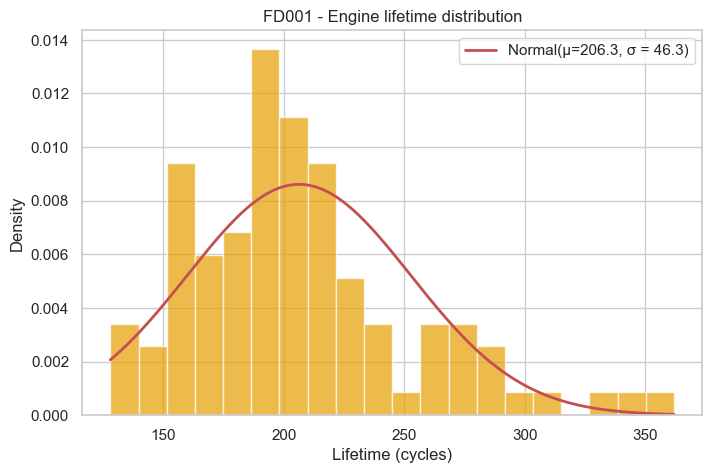

min:    128
max:    362
mean:   206.3
median: 199.0


In [3]:
# Cell: Basic sanity checks
# --------
# What this cell should do:
#   1. Number of unique engines in train and test
#   2. Distribution of engine lifetimes in train (histogram)
#   3. Print min, max, mean, median lifetime
# Expected: ~100 engines, lifetimes ranging ~128 to ~362 cycles, mean ~206

# YOUR CODE HERE

# Finding unique numbers of engines in train andn test

n_train = train['unit_id'].nunique()
n_test = test['unit_id'].nunique()
print(f'train engine: {n_train}')
print(f'test engine: {n_test}')

# Making the histogram

lifetimes = train.groupby('unit_id')['cycle'].max()
mu, sigma = lifetimes.mean(), lifetimes.std()

fig, ax = plt.subplots(figsize = (8,5))
ax.hist(lifetimes, bins = 20, density = True, alpha = 0.7)

x = np.linspace(lifetimes.min(), lifetimes.max(), 200)
ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw = 2, label = f'Normal(µ={mu:.1f}, σ = {sigma:.1f})')
ax.set_xlabel('Lifetime (cycles)')
ax.set_ylabel('Density')
ax.set_title('FD001 - Engine lifetime distribution')
ax.legend()
plt.show()

# Printing key numbers

print(f'min:    {lifetimes.min()}')
print(f'max:    {lifetimes.max()}')
print(f'mean:   {lifetimes.mean():.1f}')
print(f'median: {lifetimes.median():.1f}')



In [4]:
# Cell: Compute RUL column for training data
# --------
# For each engine, RUL at cycle c = max_cycle_for_that_engine - c
# This is your training target. Use groupby + transform.
# Hint: train['RUL'] = train.groupby('unit_id')['cycle'].transform('max') - train['cycle']

# YOUR CODE HERE

train['RUL'] = train.groupby('unit_id')['cycle'].transform('max') - train['cycle']

# sanity check
eng1 = train[train['unit_id'] == 1][['cycle', 'RUL']]
print(eng1.head())
print(eng1.tail())


   cycle  RUL
0      1  191
1      2  190
2      3  189
3      4  188
4      5  187
     cycle  RUL
187    188    4
188    189    3
189    190    2
190    191    1
191    192    0


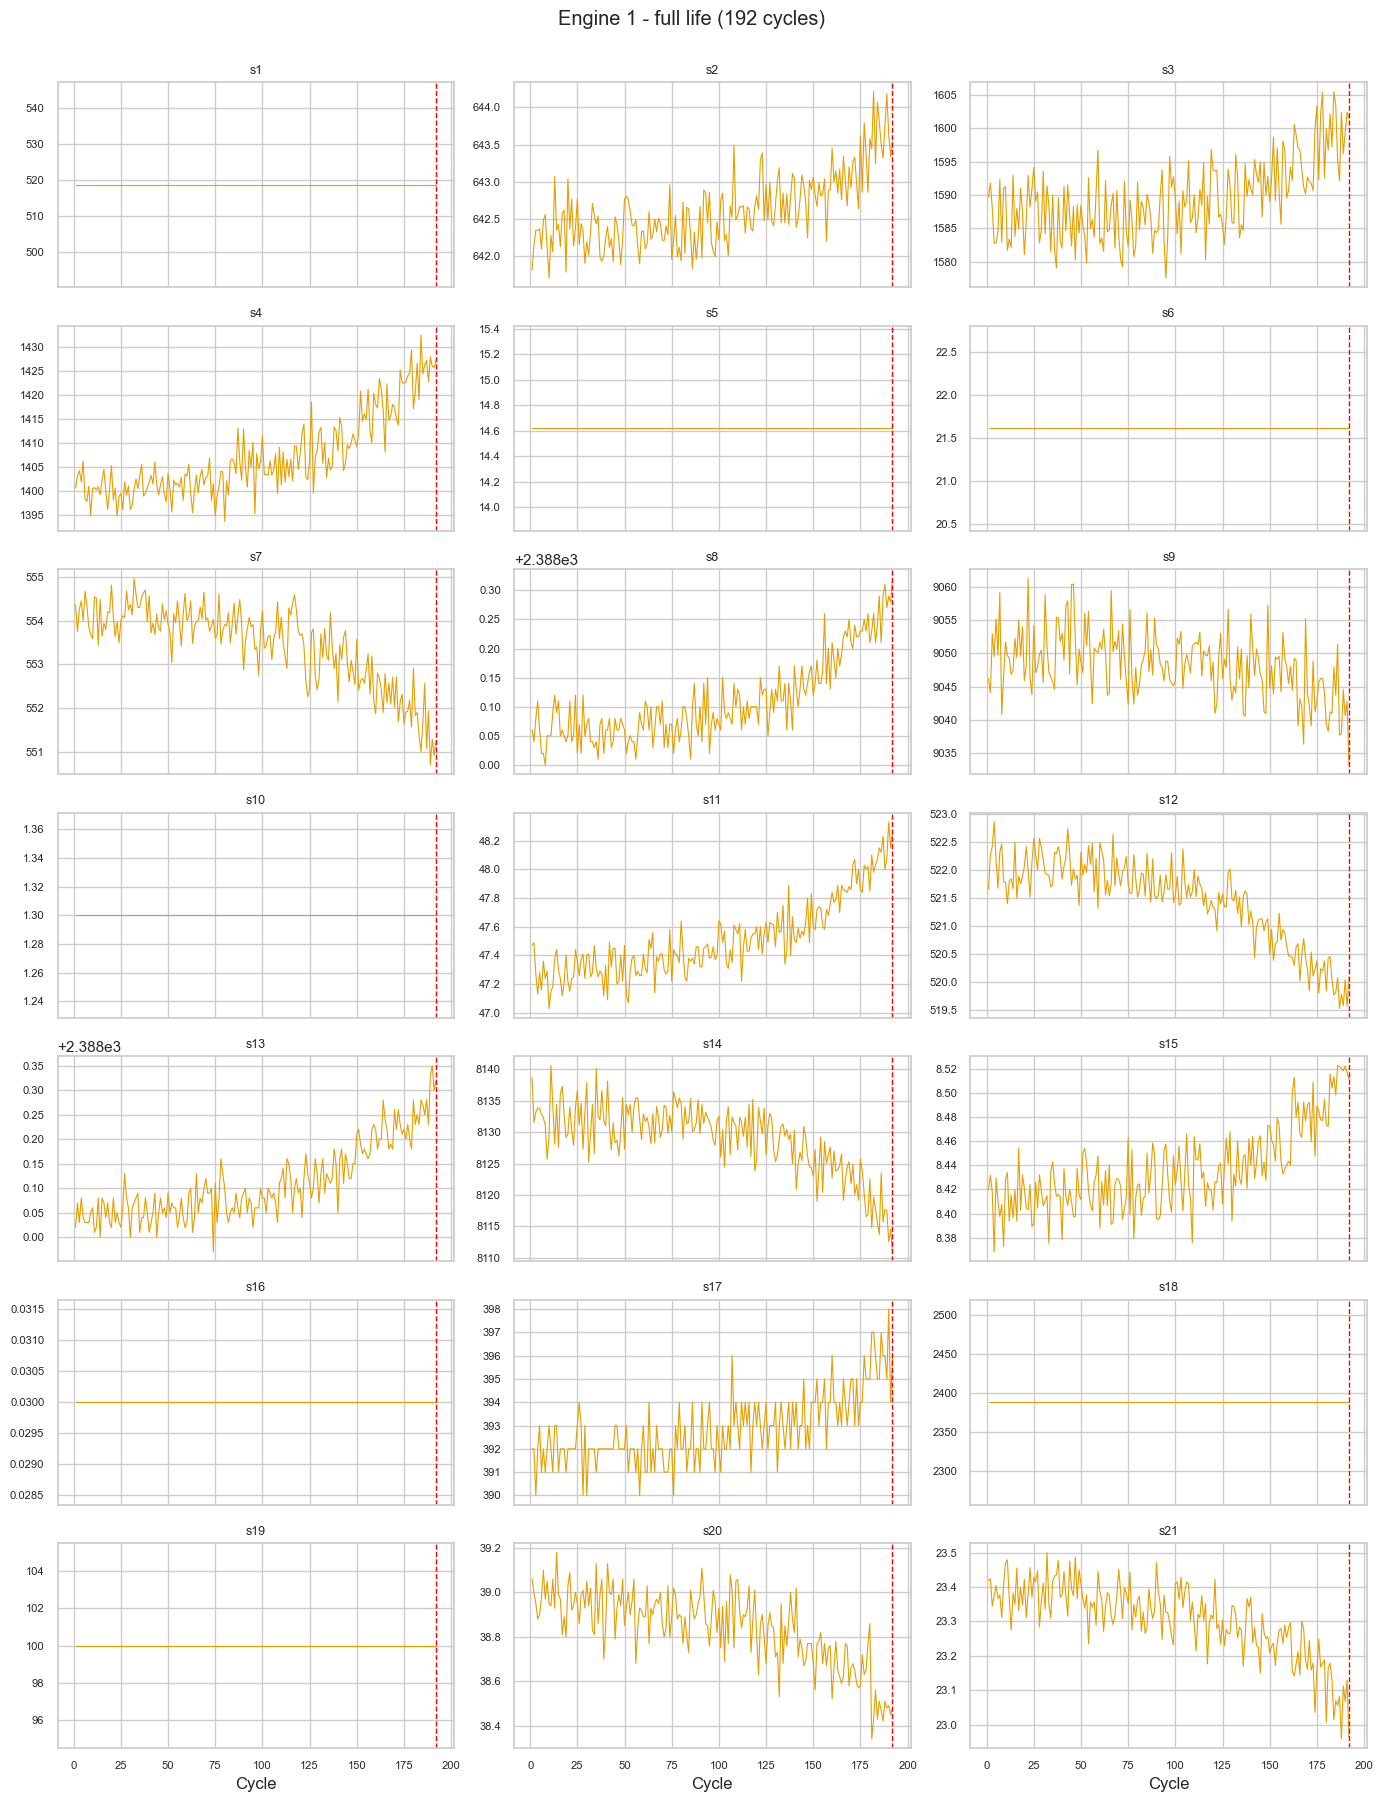

In [5]:
# Cell: Visualize one engine's full life
# --------
# Pick unit_id=1. Plot all 21 sensors over its lifetime in a 7x3 grid of subplots.
# Mark the last cycle with a vertical red line.
# You'll see: most sensors flat with noise, some with clear drift in the last 30% of life.

# YOUR CODE HERE

eng = train[train['unit_id'] == 1]
last_cycle = eng['cycle'].max()
sensors = [f's{i}' for i in range(1,22)]

fig, axes = plt.subplots(7, 3, figsize = (14,18), sharex = True)

for ax, sensor in zip(axes.flat, sensors):
    ax.plot(eng['cycle'], eng[sensor], lw = 0.8)
    ax.axvline(last_cycle, color = 'red', lw = 1, ls = '--')
    ax.set_title(sensor, fontsize = 9)
    ax.tick_params(labelsize = 8)

for ax in axes[-1, :]:
    ax.set_xlabel('Cycle')

fig.suptitle(f'Engine 1 - full life ({last_cycle} cycles)', y = 1.00)
fig.tight_layout()
plt.show()


---

# Week 1 — EDA and baseline establishment

**Goal of this week**: figure out which sensors carry information, and establish a "healthy" baseline per engine.

In [6]:
# Cell: Identify informative sensors
# --------
# For each sensor s1..s21, compute three quantities across the full training set:
#   (a) overall variance — constant sensors have variance ~0, useless
#   (b) mean trend coefficient: slope of sensor vs cycle averaged across engines
#   (c) Pearson correlation between sensor value and RUL
#
# Expected result: sensors 1, 5, 6, 10, 16, 18, 19 are nearly constant (drop them).
# Sensors like 2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21 show meaningful trends.
# Produce a summary DataFrame sorted by |correlation with RUL| descending.

# YOUR CODE HERE

sensors = [f's{i}' for i in range(1,22)]
def mean_slope(sensor):
    """ Average per-engine slope of sensor vs cycle """
    slopes = train.groupby('unit_id').apply(lambda g: np.polyfit(g['cycle'], g[sensor], 1)[0])
    return slopes.mean()

rows = []

for s in sensors:
    rows.append({
        'sensor':        s, 
        'variance':      train[s].var(),
        'mean_slope':    mean_slope(s), 
        'corr_with_RUL': train[s].corr(train['RUL']),
    })

sensor_stats = pd.DataFrame(rows) # DataFrame with columns: sensor, variance, mean_slope, corr_with_RUL
sensor_stats = sensor_stats.reindex(sensor_stats['corr_with_RUL'].abs().sort_values(ascending = False).index).reset_index(drop = True)

sensor_stats


/Users/mikkelpeluffojohansen/anaconda3/envs/py312/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mikkelpeluffojohansen/anaconda3/envs/py312/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,sensor,variance,mean_slope,corr_with_RUL
0,s11,7.133568e-02,3.376082e-03,-6.962281e-01
1,s4,8.101089e+01,1.109179e-01,-6.789482e-01
2,s12,5.439850e-01,-9.034210e-03,6.719831e-01
3,s7,7.833883e-01,-1.054778e-02,6.572227e-01
4,s15,1.406628e-03,4.376785e-04,-6.426670e-01
5,s21,1.171825e-02,-1.249195e-03,6.356620e-01
6,s20,3.266927e-02,-2.084465e-03,6.294285e-01
7,s2,2.500533e-01,5.488195e-03,-6.064840e-01
8,s17,2.398667e+00,1.701734e-02,-6.061536e-01
9,s3,3.759099e+01,6.514257e-02,-5.845204e-01


In [7]:
# Cell: Keep the informative sensors
# --------
# Define USEFUL_SENSORS as the list of sensor names you'll carry forward.
# Aim for 10-14 sensors. Document your threshold choice in a comment.

# YOUR CODE HERE
mask = (sensor_stats['variance'] > 1e-6) & (sensor_stats['corr_with_RUL'].abs())
USEFUL_SENSORS = sensor_stats.loc[mask, 'sensor'].tolist()

print(f'{len(USEFUL_SENSORS)} useful sensors:')
print(USEFUL_SENSORS)


15 useful sensors:
['s11', 's4', 's12', 's7', 's15', 's21', 's20', 's2', 's17', 's3', 's8', 's13', 's9', 's14', 's6']


In [8]:
# Cell: Compute per-engine baseline
# --------
# For each engine, during its first N_BASELINE_CYCLES (try 30), compute the mean
# and std of each useful sensor. Store in a dict or DataFrame keyed by unit_id.
#
# Then z-score-normalize all sensor values using each engine's own baseline:
#     z = (value - engine_baseline_mean) / engine_baseline_std
#
# Replace z-scores in train and test DataFrames with new columns s{i}_z.

N_BASELINE_CYCLES = 30

# YOUR CODE HERE


In [9]:
# Cell: Visualize z-scored trajectories
# --------
# Plot z-scored sensor trajectories for 5 engines of varying lifetimes.
# Put all 5 engines on the same plot per sensor (use 4-6 sensors as subplots).
# You should see z-scores cluster around 0 early, then drift systematically as engines age.

# YOUR CODE HERE

N_BASELINE_CYCLES = 30

def compute_baseline(df, sensors, n = N_BASELINE_CYCLES):
    """ Return (means, stds) Dataframes indexed by unit_id, columns = sensors. """

    early = df[df['cycle'] <= n].groupby('unit_id')[sensors]
    return early.mean(), early.std()

def add_zscores(df, sensors, means, stds):
    """ Add s{i}_z columns: Each cycle z-scored against its engine's own base line. """
    for s in sensors:
        m = df['unit_id'].map(means[s])
        sd = df['unit_id'].map(stds[s]).replace(0,1)
        df[f'{s}_z'] = (df[s]-m) / sd
    return df

train_means, train_stds = compute_baseline(train, USEFUL_SENSORS)
train = add_zscores(train, USEFUL_SENSORS, train_means, train_stds)

test_means, test_stds = compute_baseline(test, USEFUL_SENSORS)
test = add_zscores(test, USEFUL_SENSORS, test_means, test_stds)

sample = train[(train['unit_id'] == 1) & (train['cycle'] <= N_BASELINE_CYCLES)]

print(sample[[f'{s}_z' for s in USEFUL_SENSORS]].describe().loc[['mean', 'std']])

             s11_z          s4_z         s12_z          s7_z         s15_z  \
mean  2.032448e-14 -1.304142e-14 -5.091483e-14 -9.103829e-14  1.242710e-14   
std   1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   

             s21_z         s20_z          s2_z         s17_z          s3_z  \
mean -3.595457e-14 -2.240800e-14  2.192209e-13 -3.870978e-15 -1.842230e-14   
std   1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   

              s8_z         s13_z          s9_z         s14_z  s6_z  
mean  2.715267e-12 -1.181143e-11  4.080810e-14 -1.088759e-13   0.0  
std   1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   0.0  


Detected: 100/100 engines (100%)
Median lead time:  76 cycles before failure
Mean   lead time:  78.7 cycles before failure


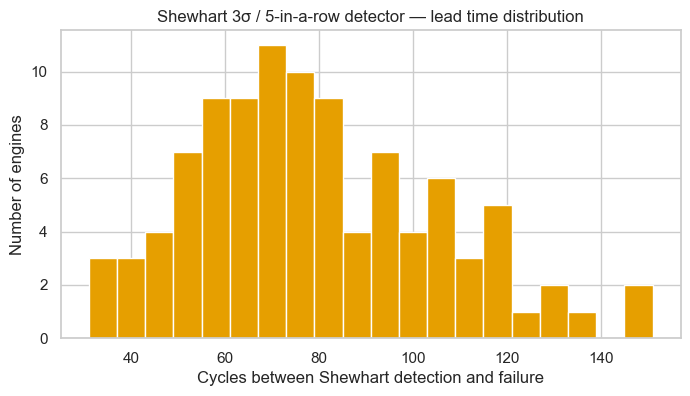

In [10]:
# Cell: Simple Shewhart control chart detector
# --------
# For each engine, flag the first cycle where ANY useful sensor's z-score exceeds ±3σ
# for 5 consecutive cycles. Call this the "detection cycle."
# Report: median cycles-before-failure at which Shewhart detection fires.
# This is your baseline method to beat later.

# YOUR CODE HERE

SHEWHART_K = 3.0
RUN_LENGTH = 5
z_cols = [f'{s}_z' for s in USEFUL_SENSORS]

def detection_cycle(group):
    out_of_control = (group[z_cols].abs() > SHEWHART_K).any(axis=1)
    run_complete = out_of_control.rolling(RUN_LENGTH).sum() >= RUN_LENGTH
    if not run_complete.any():
        return np.nan
    first_idx = run_complete.idxmax()      # first True
    return group.loc[first_idx, 'cycle']

detections = train.groupby('unit_id').apply(detection_cycle)
lifetimes  = train.groupby('unit_id')['cycle'].max()
lead_time  = lifetimes - detections        # cycles between detection and failure

n_detected = detections.notna().sum()
print(f'Detected: {n_detected}/{len(detections)} engines '
      f'({100*n_detected/len(detections):.0f}%)')
print(f'Median lead time:  {lead_time.median():.0f} cycles before failure')
print(f'Mean   lead time:  {lead_time.mean():.1f} cycles before failure')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lead_time.dropna(), bins=20)
ax.set_xlabel('Cycles between Shewhart detection and failure')
ax.set_ylabel('Number of engines')
ax.set_title('Shewhart 3σ / 5-in-a-row detector — lead time distribution')
plt.show()


---

# Week 2 — Kalman filtering

**Required reading before this week**: Chapters 1-4 of Roger Labbe's "Kalman and Bayesian Filters in Python" — https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python

**Key idea**: the true sensor value is a slowly changing hidden state; your measurement is that state plus noise. The Kalman filter estimates the hidden state optimally and quantifies uncertainty.

In [11]:
# Cell: Import filterpy and implement 1D Kalman filter
# --------
# For a scalar state with constant-velocity model (state = [value, rate_of_change]):
#   - state transition matrix F = [[1, dt], [0, 1]]
#   - observation matrix H = [[1, 0]]
#   - process noise Q controls how fast the true value can change
#   - measurement noise R controls how noisy the sensor is
#
# Start with Q = diag([1e-4, 1e-5]) and R = 1.0 (since you're working in z-scores)
# Tune these by looking at results.

# !pip install filterpy
from filterpy.kalman import KalmanFilter

def make_kf(dt=1.0, q=1e-4, r=1.0):
    '''Return a 2-state (value + rate) Kalman filter.'''
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.F = np.array( # Constant velocity dynamics
        [
            [1.0,dt], 
            [0.0,1.0] 
        ]
    )
    kf.H = np.array([[1.0,0.0]]) # Observed value not rate
    kf.Q = np.array([[q, q * 0.1]]) # Process noise on value and rate
    kf.R = np.array([[r]]) # Measurement noise variance
    kf.P = np.eye(2) *1.0 # Initial state uncertainty
    kf.x = np.array([0.0, 0.0]) # Initial state: z-scores start near 0

    return kf

# F: Propagates state forward: value_next = value + rate * dt, rate_next = rate
# Constant velocity means we expect smooth drift, not jumps
# H: maps state to measurement: We only directly see the value not the rate
# Q says the true state can wander tihs much per step. Bigger Q = filter trust the data, smaller Q = filter trust the model more
# R is measurement noise variance. Since we've z-scored, R = 1.0 is a sensible default
# P is out prior uncertainty about the initial state
# x is the initial state guess


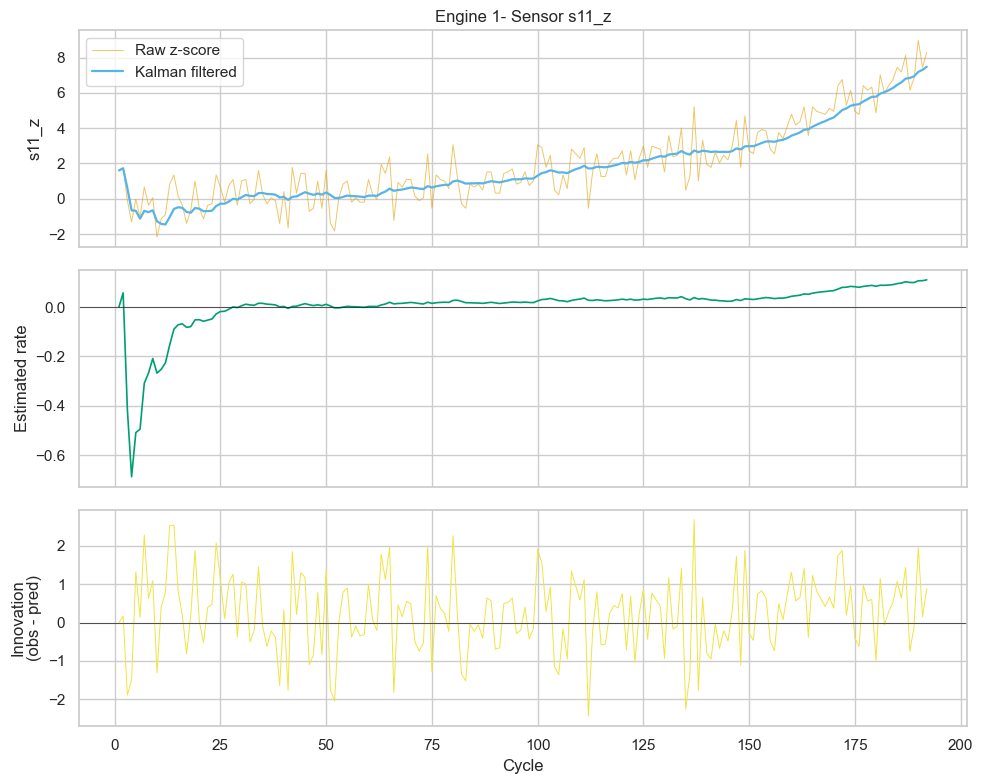

In [12]:
# Cell: Apply Kalman filter to one sensor of one engine
# --------
# Pick engine 1, sensor s11_z. Run the Kalman filter through its entire life.
# At each step, record:
#   - filtered value (kf.x[0])
#   - filtered rate (kf.x[1])
#   - innovation (observation - prediction, kf.y)
#
# Plot raw z-score, filtered value, and innovation as three stacked subplots.
# The innovations should look like zero-mean noise early, then drift late.

# YOUR CODE HERE

eng = train[train['unit_id'] == 1].sort_values('cycle')
obs = eng['s11_z'].values
cycles = eng['cycle'].values

kf = make_kf(dt = 1.0, q = 1e-4)
kf.x = np.array([obs[0], 0.0])

filtered_val = np.empty(len(obs))
filtered_rate = np.empty(len(obs))
innovation = np.empty(len(obs))

for i, z in enumerate(obs):
    kf.predict()
    kf.update(z)
    filtered_val[i] = kf.x[0]
    filtered_rate[i] = kf.x[1]
    innovation[i] = kf.y.item()

fig, axes = plt.subplots(3, 1, figsize = (10,8), sharex = True)

axes[0].plot(cycles, obs, lw = 0.7, label = 'Raw z-score', alpha = 0.6)
axes[0].plot(cycles, filtered_val, lw = 1.6, label = 'Kalman filtered')
axes[0].set_ylabel('s11_z')
axes[0].legend(loc = 'upper left')
axes[0].set_title('Engine 1- Sensor s11_z')

axes[1].plot(cycles, filtered_rate, lw = 1.2, color = 'C2')
axes[1].axhline(0, color = 'k', lw = 0.5)
axes[1].set_ylabel('Estimated rate')

axes[2].plot(cycles, innovation, lw = 0.7, color = 'C3')
axes[2].axhline(0, color = 'k', lw = 0.5)
axes[2].set_ylabel('Innovation\n(obs - pred)')
axes[2].set_xlabel('Cycle')

fig.tight_layout()
plt.show()

In [13]:
# Cell: Apply Kalman filter across all engines and all useful sensors
# --------
# Build a function kalman_filter_engine(engine_df, sensors) that returns
# a DataFrame with columns: cycle, filtered_<sensor>, rate_<sensor>, innovation_<sensor>.
# Apply to every engine in train. Store results in a dict keyed by unit_id.
# Warning: this might take a minute across ~100 engines x ~14 sensors.

# YOUR CODE HERE

def kalman_filter_engine(engine_df, sensors, q = 1e-4, r = 1.0):
    """ 

    Run a Kalman filter on each {sensor}_z column. Returning a DataFrame
    with cycle + filtered_/rate/innovation columns per sensor

    """

    engine_Df = engine_df.sort_values('cycle')
    out = {'cycle': engine_df['cycle'].values}

    for sensor in sensors:
        obs = engine_df[f'{sensor}_z'].values
        kf = make_kf(dt = 1.0, q = q, r = r)
        kf.x = np.array([obs[0], 0.0])

        fv = np.empty(len(obs))
        fr = np.empty(len(obs))
        inv = np.empty(len(obs))

        for i, z in enumerate(obs):
            kf.predict()
            kf.update(z)
            fv[i] = kf.x[0]
            fr[i] = kf.x[1]
            inv[i] = kf.y.item()
        
        out[f'filtered_{sensor}'] = fv
        out[f'rate_{sensor}'] = fr
        out[f'innovation_{sensor}'] = inv
    
    return pd.DataFrame(out)

kalman_train = {
    uid: kalman_filter_engine(g, USEFUL_SENSORS)
    for uid, g, in train.groupby('unit_id')
}

print(f'Filtered {len(kalman_train)} engines.')
print(f'Engine 1 result shape: {kalman_train[1].shape}')
print(f'Columns: {kalman_train[1].columns[:6].tolist()}')
kalman_train[1].head()



Filtered 100 engines.
Engine 1 result shape: (192, 46)
Columns: ['cycle', 'filtered_s11', 'rate_s11', 'innovation_s11', 'filtered_s4', 'rate_s4']


,cycle,filtered_s11,rate_s11,innovation_s11,filtered_s4,rate_s4,innovation_s4,filtered_s12,rate_s12,innovation_s12,...,innovation_s13,filtered_s9,rate_s9,innovation_s9,filtered_s14,rate_s14,innovation_s14,filtered_s6,rate_s6,innovation_s6
0,1,1.608438,0.000000,0.000000,0.169926,0.000000,0.000000,-1.080034,0.000000,0.000000,...,0.000000,-0.774505,0.000000,0.000000,1.654331,0.000000,0.000000,0.0,0.0,0.0
1,2,1.722919,0.057244,0.171719,0.753983,0.292044,0.876071,0.030469,0.555280,1.665724,...,1.693928,-1.091642,-0.158577,-0.475698,0.341229,-0.656585,-1.969617,0.0,0.0,0.0
2,3,0.599564,-0.415039,-1.888919,1.274516,0.383448,0.365573,0.820799,0.649309,0.376072,...,-1.355203,-0.006244,0.339059,1.990318,-0.014891,-0.536388,0.480734,0.0,0.0,0.0
3,4,-0.658317,-0.686970,-1.495315,1.066125,0.192499,-1.050002,1.849921,0.771850,0.673840,...,0.959902,0.124775,0.271938,-0.369090,-0.053908,-0.375918,0.882403,0.0,0.0,0.0
4,5,-0.678100,-0.508205,1.322391,1.687321,0.307364,0.849695,1.472510,0.463918,-2.277880,...,-1.336701,0.820155,0.385394,0.839278,-0.050085,-0.274170,0.752663,0.0,0.0,0.0


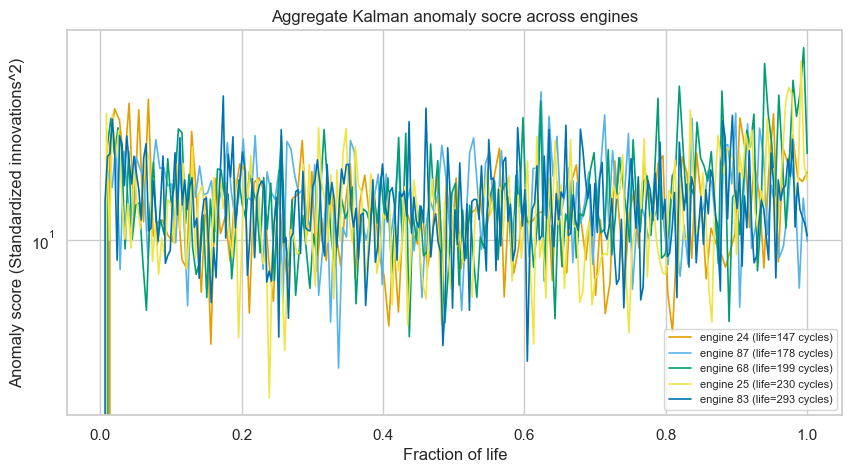

In [14]:
# Cell: Build an aggregate anomaly score
# --------
# For each engine at each cycle, compute:
#     anomaly_score(cycle) = sum over sensors of (innovation / expected_std)^2
# This is a Mahalanobis-like distance. Healthy engines should have small scores.
# Degrading engines should have growing scores.
#
# Plot anomaly scores for 5 engines vs cycle. Normalize cycle to fraction of life
# (cycle / max_cycle) so engines of different lifetimes overlay cleanly.

# YOUR CODE HERE

N_HEALTHY = 30

def anomaly_score(filtered_df, sensors, n_healthy = N_HEALTHY):
    score = np.zeros(len(filtered_df))
    for s in sensors:
        innov = filtered_df[f'innovation_{s}'].values
        sigma = innov[:n_healthy].std()
        if sigma < 1e-8:
            sigma = 1.0
        score += (innov / sigma) ** 2
    return score

for uid, df in kalman_train.items():
    df['anomaly'] = anomaly_score(df, USEFUL_SENSORS)

lifetimes = train.groupby('unit_id')['cycle'].max()
sample_uids = lifetimes.sort_values().iloc[[5, 25, 50, 75, 95]].index.tolist()

fig, ax = plt.subplots(figsize = (10, 5))
for uid in sample_uids:
    df = kalman_train[uid]
    life_frac = df['cycle'] / df['cycle'].max()
    ax.plot(life_frac, df['anomaly'], lw = 1.2, label = f'engine {uid} (life={df["cycle"].max()} cycles)')

ax.set_xlabel('Fraction of life')
ax.set_ylabel('Anomaly score (Standardized innovations^2)')
ax.set_title('Aggregate Kalman anomaly socre across engines')
ax.set_yscale('log')
ax.legend(fontsize = 8)
plt.show()

---

# Week 3 — RUL prediction via similarity

**Key idea**: to predict RUL of a test engine, find the most similar training engine and borrow its remaining life.

In [15]:
# Cell: Define trajectory distance
# --------
# Given two engine trajectories (numpy arrays of shape [n_cycles, n_features]),
# compute a distance. Start simple: take the last W cycles of each (try W=30),
# and compute Euclidean distance.
#
# Later you can upgrade to Dynamic Time Warping using dtaidistance.

def trajectory_distance(traj_a, traj_b, window=30):
    '''
    Distance between the last `window` cycles of two trajectories.
    Each trajecotry is shape [n_cycles, n_features]. If either is shorter than window
    we shrink the comparison length so alignment stays sensible
    '''

    w = min(len(traj_a), len(traj_b), window)
    a = traj_a[-w:]
    b = traj_b[-w:]
    return np.sqrt(np.sum((a - b) ** 2))

sensors = USEFUL_SENSORS

e1 = train[train['unit_id'] == 1][[f'{s}_z' for s in sensors]].values
e2 = train[train['unit_id'] == 1][[f'{s}_z' for s in sensors]].values

print('self :', trajectory_distance(e1, e1))
print('noisy :', trajectory_distance(e1, e1 + np.random.normal(0, 0.05, e1.shape)))
print('e1↔e2 :', trajectory_distance(e1, e2))

self : 0.0
noisy : 1.0264302145729471
e1↔e2 : 0.0


In [16]:
# Cell: Similarity-based RUL predictor
# --------
# For each test engine:
#   1. Take its last W cycles of z-scored useful sensors
#   2. For each TRAINING engine, find the best alignment (try all start positions)
#   3. Record the training engine's remaining cycles from that alignment point
#   4. Predict RUL as weighted average of k nearest neighbors (try k=5)
#
# Output: DataFrame with test_unit_id, predicted_RUL, true_RUL (from RUL file).

# YOUR CODE HERE

W = 30
K = 5

sensor_z_cols = [f'{s}_z' for s in USEFUL_SENSORS]
train_arrays = {
    uid: g.sort_values('cycle')[sensor_z_cols].values for uid, g in train.groupby('unit_id')
}

def predict_rul_similarity(test_traj, train_arrays, window = W, k = K):
    if len(test_traj) < window:
        return np.nan
    test_tail = test_traj[-window:]

    candidates = []
    for traj in train_arrays.values():
        L = len(traj)
        if L < window:
            continue
        for p in range(L - window + 1):
            d = np.sqrt(np.sum((test_tail - traj[p:p + window]) ** 2))
            remaining = L - (p + window)
            candidates.append((d, remaining))

    candidates.sort(key = lambda x: x[0])
    top = candidates[:k]
    dists = np.array([d for d, _ in top])
    remaining = np.array([r for _, r in top])
    weights = 1.0 / (dists + 1e-6)
    return float(np.average(remaining, weights = weights))

results = []

for uid, g in test.groupby('unit_id'):
    g = g.sort_values('cycle')
    test_traj = g[sensor_z_cols].values
    pred = predict_rul_similarity(test_traj, train_arrays)
    results.append({
        'test_unit_id': uid, 
        'predicted_RUL': pred, 
        'true_RUL': rul.loc[uid, 'RUL'],
    })

predictions_sim = pd.DataFrame(results)
print(f'Predictions: {predictions_sim.shape[0]}, '
      f'NaN preds: {predictions_sim["predicted_RUL"].isna().sum()}')
predictions_sim.head()

Predictions: 100, NaN preds: 0


,test_unit_id,predicted_RUL,true_RUL
0,1,172.820565,112
1,2,199.368123,98
2,3,40.230757,69
3,4,66.258311,82
4,5,59.000631,91


In [17]:
# Cell: Evaluate using CMAPSS scoring function
# --------
# Official score penalizes late predictions harder than early ones.
# For each engine, d = predicted - true. Score contribution:
#   if d < 0:  exp(-d/13) - 1    (early prediction, penalty moderate)
#   if d >= 0: exp(d/10) - 1     (late prediction, penalty severe)
# Total score = sum across engines. Lower is better. Also report RMSE.

def cmapss_score(pred, true):
    ''' CMAPSS official asymmetric scoring function.
        Late predictions (d > 0) penalized harder than earlier ones (d < 0).
    '''
    pred = np.asarray(pred, dtype = float)
    true = np.asarray(true, dtype = float)

    d = pred - true

    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

pred = predictions_sim['predicted_RUL'].values
true = predictions_sim['true_RUL'].values

rmse = float(np.sqrt(np.mean((pred - true) ** 2)))
score = cmapss_score(pred, true)
mae = float(np.mean(np.abs(pred - true)))

print(f'Similarity baseline')
print(f' RMSE:          {rmse:.2f}')
print(f' MAE:           {mae:.2f}')
print(f' CMAPSS score:  {score:.1f}')


Similarity baseline
 RMSE:          34.64
 MAE:           25.87
 CMAPSS score:  46315.9


Late predictions: 54/100(54%)
Worst late error: 101 cycles


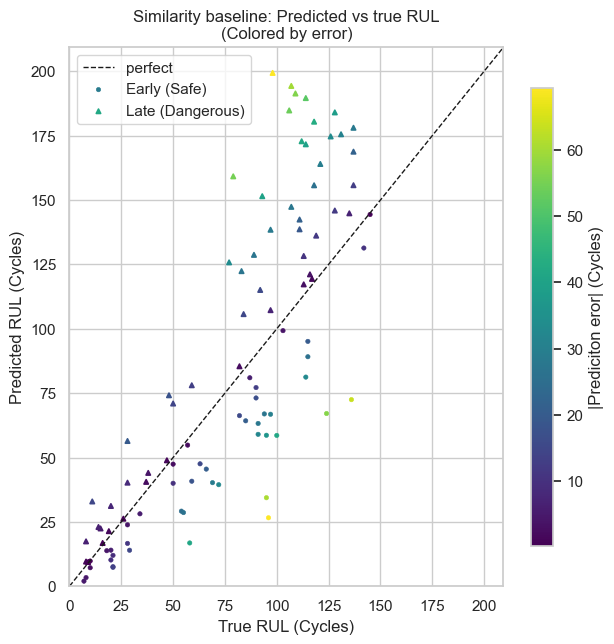

In [18]:
# Cell: Plot predicted vs true RUL
# --------
# Scatter plot, diagonal reference line, highlight points above the line (late
# predictions = dangerous). Color by absolute error.

# YOUR CODE HERE

pred = predictions_sim['predicted_RUL'].values
true = predictions_sim['true_RUL'].values
abs_err = np.abs(pred - true)
late_mask = pred > true

lim = max(true.max(), pred.max()) * 1.05

fig, ax = plt.subplots(figsize = (7,7))

ax.plot([0, lim], [0, lim], 'k--', lw = 1, label = 'perfect')

# Safe, early, predictions
sc = ax.scatter(true[~late_mask], pred[~late_mask], c = abs_err[~late_mask], cmap = 'viridis', s = 10, linewidth = 0.4, label = 'Early (Safe)')

# Late, dangerous, predictions
ax.scatter(true[late_mask], pred[late_mask], c = abs_err[late_mask], cmap = 'viridis', marker = '^', s = 10, linewidth = 1.2, label = 'Late (Dangerous)')

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel('True RUL (Cycles)')
ax.set_ylabel('Predicted RUL (Cycles)')
ax.set_title('Similarity baseline: Predicted vs true RUL\n(Colored by error)')
ax.legend(loc = 'upper left')
cbar = fig.colorbar(sc, ax = ax, shrink = 0.85)
cbar.set_label('|Prediciton eror| (Cycles)')

print(f'Late predictions: {late_mask.sum()}/{len(pred)}'
      f'({100 * late_mask.mean():.0f}%)')
print(f'Worst late error: {abs_err[late_mask].max():.0f} cycles')
plt.show()

---

# Week 4 — Regression models

**Required reading**: James, Witten, Hastie, Tibshirani — "An Introduction to Statistical Learning" chapter 8 (trees + ensembles). Free at https://www.statlearning.com/

In [19]:
# Cell: Build feature matrix for regression
# --------
# For each row in train, features = current z-scored sensor values + rolling
# window statistics (mean, std, min, max over last 10 cycles) for each useful sensor.
# Target = RUL column you computed in Week 0.
#
# Clip RUL at an upper bound (try 125) — engines far from failure are hard to
# predict and bias the model. This is a standard CMAPSS trick.

RUL_CLIP = 125
ROLL_WINDOW = 10

z_cols = [f'{s}_z' for s in USEFUL_SENSORS]

def build_features(df):
    """ 
    Return feature DataFrame: Current z-scores + rolling mean/std/min/max
    over the last ROLL_WINDOW cycles, computed per engine
    """

    df = df.sort_values(['unit_id', 'cycle'])
    g = df.groupby('unit_id')[z_cols].rolling(window = ROLL_WINDOW, min_periods = 1)

    cur = df[z_cols]
    means = g.mean().reset_index(level = 0, drop = True).add_suffix('_mean')
    stds = g.std().reset_index(level = 0, drop = True).add_suffix('_std').fillna(0)
    mins = g.min().reset_index(level = 0, drop = True).add_suffix('_min')
    maxs = g.max().reset_index(level = 0, drop = True).add_suffix('_max')

    feats = pd.concat([cur, means, stds, mins, maxs], axis = 1)
    return feats.loc[df.index]

train_sorted = train.sort_values(['unit_id', 'cycle'])
X_train_df = build_features(train_sorted)
X_train = X_train_df.values
y_train = np.minimum(train_sorted['RUL'].values, RUL_CLIP)

test_sorted = test.sort_values(['unit_id', 'cycle'])
X_test_df = build_features(test_sorted)
last_idx = test_sorted.groupby('unit_id')['cycle'].idxmax()
X_test = X_test_df.loc[last_idx].values
y_test = np.minimum(rul['RUL'].values, RUL_CLIP)

print(f'X_train: {X_train.shape}    y_train: {y_train.shape}'
      f'range [{y_train.min()}, {y_train.max()}]')

print(f'X_test: {X_test.shape}  y_test: {y_test.shape}'
      f'range [{y_test.min()}, {y_test.max()}]')
print(f'Feature columns: {X_train_df.shape[1]}'
      f'(= {len(USEFUL_SENSORS)} sensors × 5 stats)')

X_train: (20631, 75)    y_train: (20631,)range [0, 125]
X_test: (100, 75)  y_test: (100,)range [7, 125]
Feature columns: 75(= 15 sensors × 5 stats)


In [20]:
# Cell: Fit Random Forest baseline
# --------
# sklearn.ensemble.RandomForestRegressor(n_estimators=200, random_state=42)
# Fit, predict on test, compute cmapss_score and RMSE.
# Print feature importance ranked top 10 — should mostly be sensor rolling means.

from sklearn.ensemble import RandomForestRegressor

# YOUR CODE HERE

import time

t0 = time.time()
rf = RandomForestRegressor(n_estimators = 200, random_state = 42, n_jobs = -1)
rf.fit(X_train, y_train)
fit_time = time.time() - t0

t0 = time.time()
pred_rf = rf.predict(X_test)
pred_time_ms = 1000 * (time.time() - t0) / len(X_test)

rmse = float(np.sqrt(np.mean((pred_rf - y_test) ** 2)))
score = cmapss_score(pred_rf, y_test)

print(f'random Forest Baseline')
print(f' fit time: {fit_time:.1f}s')
print(f' pred time/eng: {pred_time_ms:.2f} ms')
print(f' RMSE: {rmse:.2f}')
print(f' CMAPSS score: {score:.1f}')

importances = pd.Series(rf.feature_importances_, index = X_train_df.columns).sort_values(ascending = False)
print('\nTop 10 features by importance')
print(importances.head(10))

random Forest Baseline
 fit time: 92.4s
 pred time/eng: 1.14 ms
 RMSE: 15.58
 CMAPSS score: 375.6

Top 10 features by importance
s15_z_mean    0.636739
s4_z_mean     0.101515
s11_z_mean    0.062772
s3_z_mean     0.028911
s14_z_mean    0.017226
s6_z_max      0.015116
s20_z_mean    0.008748
s13_z_mean    0.007586
s14_z_min     0.006946
s12_z_mean    0.005660
dtype: float64


Note: you may need to restart the kernel to use updated packages.


/Users/mikkelpeluffojohansen/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mikkelpeluffojohansen/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mikkelpeluffojohansen/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM quantile regression
median RMSE: 16.97
mediam CMAPSS: 528.7
80% interval cov.: 0.36 (target ~0.80)
mean interval width: 62.3 cycles


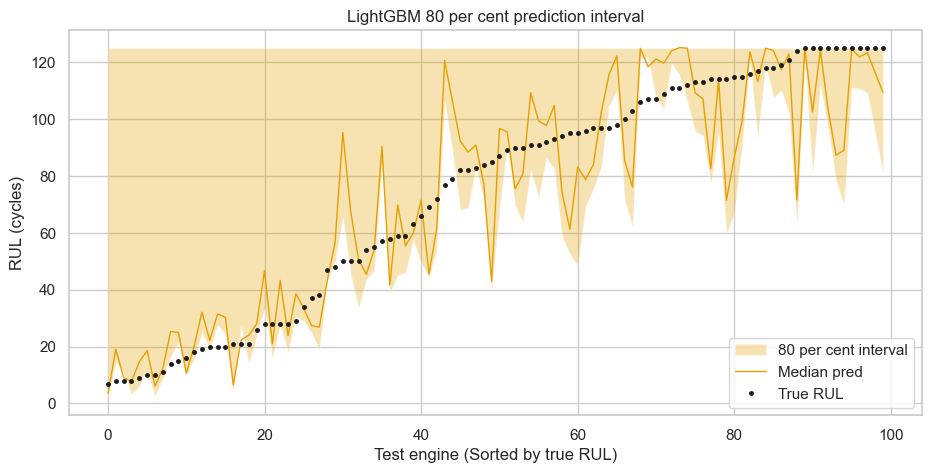

In [26]:
# Cell: LightGBM with quantile regression
# --------
# Fit THREE separate LightGBM models predicting the 0.1, 0.5, 0.9 quantiles.
# Each model uses objective='quantile', alpha=<quantile_level>.
# Report: point (median) predictions' RMSE AND coverage of the [0.1, 0.9] interval.
# Coverage = fraction of test engines where true RUL falls in [pred_0.1, pred_0.9].
# Well-calibrated 80% intervals should have coverage ≈ 0.80.
%pip install lightgbm
import lightgbm as lgb

# YOUR CODE HERE

QUANTILES = [0.1, 0.5, 0.9]
common_params = dict(
    objective = 'quantile', 
    n_estimators = 400, 
    learning_rate = 0.05, 
    num_leaves = 31, 
    min_data_in_leaf = 20, 
    random_state = 42,
    verbose = -1,
)

models = {}
preds = {}

for q in QUANTILES:
    m = lgb.LGBMRegressor(alpha = q, **common_params)
    m.fit(X_train, y_train)
    models[q] = m
    preds[q] = m.predict(X_test)

p10, p50, p90 = preds[0.1], preds[0.5], preds[0.9]

rmse_med = float(np.sqrt(np.mean((p50 - y_test) ** 2)))
score_med = cmapss_score(p50, y_test)
coverage_80 = float(np.mean((y_test >= p10) & (y_test <= 90)))
mean_width = float(np.mean(p90 - p10))

print('LightGBM quantile regression')
print(f'median RMSE: {rmse_med:.2f}')
print(f'mediam CMAPSS: {score_med:.1f}')
print(f'80% interval cov.: {coverage_80:.2f} (target ~0.80)')
print(f'mean interval width: {mean_width:.1f} cycles')


order = np.argsort(y_test)
fig, ax = plt.subplots(figsize = (11, 5))
xs = np.arange(len(y_test))
ax.fill_between(xs, p10[order], p90[order], alpha = 0.3, label = '80 per cent interval')
ax.plot(xs, p50[order], lw = 1, label = 'Median pred')
ax.plot(xs, y_test[order], 'k.', ms = 5, label = 'True RUL')
ax.set_xlabel('Test engine (Sorted by true RUL)')
ax.set_ylabel('RUL (cycles)')
ax.legend()
ax.set_title('LightGBM 80 per cent prediction interval')
plt.show()

In [31]:
# Cell: Benchmark table
# --------
# Build a DataFrame with rows for each method (Similarity, RandomForest, LightGBM-median)
# and columns: RMSE, CMAPSS_score, mean_prediction_time_ms.
# Print it.

# YOUR CODE HERE

t0 = time.time()
sim_preds = []
for uid, g in test.groupby('unit_id'):
    g = g.sort_values('cycle')
    sim_preds.append(predict_rul_similarity(g[sensor_z_cols].values, train_arrays))
sim_time_ms = 1000 * (time.time() - t0) / len(sim_preds)
sim_preds = np.array(sim_preds)

t0 = time.time()
pred_rf = rf.predict(X_test)
rf_time_ms = 1000 * (time.time() - t0) / len(X_test)

t0 = time.time()
pred_lgb = models[0.5].predict(X_test)
lgb_time_ms = 1000 * (time.time() - t0) / len(X_test)

def metrics(pred, true):
    rmse = float(np.sqrt(np.mean((pred - true) ** 2)))
    score = cmapss_score(pred, true)
    return rmse, score

true_unclipped = rul['RUL'].values

rmse_sim, score_sim = metrics(sim_preds, true_unclipped)
rmse_rf,  score_rf  = metrics(pred_rf,   y_test)
rmse_lgb, score_lgb = metrics(pred_lgb,  y_test)

benchmark = pd.DataFrame(
    [
        {'method': 'Similarity',       'RMSE': rmse_sim, 'CMAPSS_score': score_sim, 'pred_time_ms': sim_time_ms},
        {'method': 'RandomForest',     'RMSE': rmse_rf,  'CMAPSS_score': score_rf,  'pred_time_ms': rf_time_ms},
        {'method': 'LightGBM-median',  'RMSE': rmse_lgb, 'CMAPSS_score': score_lgb, 'pred_time_ms': lgb_time_ms},
    ]
).set_index('method')

print(benchmark.round(2))

                  RMSE  CMAPSS_score  pred_time_ms
method                                            
Similarity       34.64      46315.86        298.37
RandomForest     15.58        375.57          0.52
LightGBM-median  16.97        528.67          0.04


/Users/mikkelpeluffojohansen/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


---

# Week 5 — Uncertainty quantification

**Required reading**: Rasmussen & Williams, "Gaussian Processes for Machine Learning" chapter 2. Free at http://www.gaussianprocess.org/gpml/

100%|██████████| 100/100 [1:52:44<00:00, 67.65s/it] 


Bootstrap RF (B = 100, 100 trees each)
Median RMSE: 15.40
 90% interval cov.: 0.21 (target = 90)
mean width: 8.8 cycles


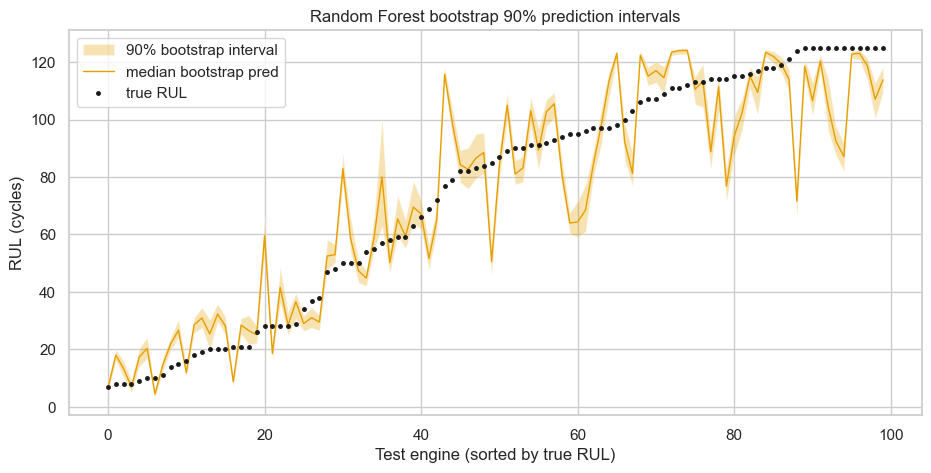

In [33]:
# Cell: Bootstrap confidence intervals for Random Forest
# --------
# Retrain the Random Forest B=100 times on bootstrap samples of X_train.
# For each test point, collect B predictions. Take 5th and 95th percentiles as bounds.
# Report interval coverage and mean width.

from tqdm import tqdm

B = 100
n_train = X_train.shape[0]
boot_preds = np.empty((B, X_test.shape[0]))

for b in tqdm(range(B)):
    idx = np.random.randint(0, n_train, size = n_train)
    rf_b = RandomForestRegressor(
        n_estimators = 100, random_state = b, n_jobs = -1
    )
    rf_b.fit(X_train[idx], y_train[idx])
    boot_preds[b] = rf_b.predict(X_test)

p05_rf = np.percentile(boot_preds, 5, axis = 0)
p50_rf = np.percentile(boot_preds, 50, axis = 0)
p95_rf = np.percentile(boot_preds, 95, axis = 0)

coverage_90 = float(np.mean((y_test >= p05_rf) & (y_test <= p95_rf)))
mean_width = float(np.mean(p95_rf - p05_rf))
rmse_med = float(np.sqrt(np.mean((p50_rf - y_test) ** 2)))

print(f'Bootstrap RF (B = {B}, 100 trees each)')
print(f'Median RMSE: {rmse_med:.2f}')
print(f' 90% interval cov.: {coverage_90:.2f} (target = 90)')
print(f'mean width: {mean_width:.1f} cycles')

order = np.argsort(y_test)
xs = np.arange(len(y_test))
fig, ax = plt.subplots(figsize = (11, 5))
ax.fill_between(xs, p05_rf[order], p95_rf[order], alpha=0.3, label='90% bootstrap interval')
ax.plot(xs, p50_rf[order], lw=1, label='median bootstrap pred')
ax.plot(xs, y_test[order], 'k.', ms=5, label='true RUL')
ax.set_xlabel('Test engine (sorted by true RUL)')
ax.set_ylabel('RUL (cycles)')
ax.legend()
ax.set_title('Random Forest bootstrap 90% prediction intervals')
plt.show()


In [38]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler

N_SUB = 1000
rng = np.random.default_rng(42)
sub_idx = rng.choice(X_train.shape[0], size=N_SUB, replace=False)

scaler = StandardScaler().fit(X_train[sub_idx])
X_sub  = scaler.transform(X_train[sub_idx])
X_te_s = scaler.transform(X_test)
y_sub  = y_train[sub_idx]

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                              n_restarts_optimizer=2, random_state=42)
print('Fitting GP (this takes 20–60s)...')
gp.fit(X_sub, y_sub)
print('Learned kernel:', gp.kernel_)

mu, sigma = gp.predict(X_te_s, return_std=True)

z90      = 1.645
lo, hi   = mu - z90 * sigma, mu + z90 * sigma
rmse     = float(np.sqrt(np.mean((mu - y_test) ** 2)))
coverage = float(np.mean((y_test >= lo) & (y_test <= hi)))
width    = float(np.mean(hi - lo))

print(f'\nGaussian Process')
print(f'  RMSE:               {rmse:.2f}')
print(f'  90% interval cov.:  {coverage:.2f}   (target ≈ 0.90)')
print(f'  mean width:         {width:.1f} cycles')

# Save for the comparison cell that comes next
gp_mu, gp_sigma = mu, sigma


Fitting GP (this takes 20–60s)...
Learned kernel: 0.714**2 * RBF(length_scale=11.6) + WhiteKernel(noise_level=0.0735)

Gaussian Process
  RMSE:               15.81
  90% interval cov.:  0.85   (target ≈ 0.90)
  mean width:         41.7 cycles


In [50]:
# Cell: Compare methods on calibration + sharpness + CRPS
%pip install properscoring
import properscoring as ps

# 1. Add 0.05 and 0.95 quantiles to LightGBM so it has a 90% interval
for q in [0.05, 0.95]:
    if q not in preds:
        m = lgb.LGBMRegressor(alpha=q, **common_params)
        m.fit(X_train, y_train)
        models[q] = m
        preds[q]  = m.predict(X_test)

quantile_levels = [0.05, 0.1, 0.5, 0.9, 0.95]
lgb_q_matrix = np.sort(np.column_stack([preds[q] for q in quantile_levels]), axis=1)
lgb_p05, lgb_p10, lgb_p50, lgb_p90, lgb_p95 = lgb_q_matrix.T

# 2. Calibration + sharpness for each method at the 90% level
def cal_sharp(lo, hi, y):
    cov   = float(np.mean((y >= lo) & (y <= hi)))
    width = float(np.mean(hi - lo))
    return cov, width

cov_lgb,  w_lgb  = cal_sharp(lgb_p05, lgb_p95, y_test)
cov_boot, w_boot = cal_sharp(p05_rf,  p95_rf,  y_test)
cov_gp,   w_gp   = cal_sharp(gp_mu - 1.645 * gp_sigma,
                             gp_mu + 1.645 * gp_sigma, y_test)

# 3. CRPS
crps_gp_arr   = ps.crps_gaussian(y_test, mu=gp_mu, sig=gp_sigma)
crps_boot_arr = ps.crps_ensemble(y_test, boot_preds.T)
crps_lgb_arr  = ps.crps_ensemble(y_test, lgb_q_matrix)

# 4. Assemble
comparison = pd.DataFrame(
    [
        {'method': 'LightGBM-quantile', 'coverage_90': cov_lgb,
         'width_90': w_lgb,  'CRPS': crps_lgb_arr.mean()},
        {'method': 'Bootstrap-RF',      'coverage_90': cov_boot,
         'width_90': w_boot, 'CRPS': crps_boot_arr.mean()},
        {'method': 'GP',                'coverage_90': cov_gp,
         'width_90': w_gp,   'CRPS': crps_gp_arr.mean()},
    ]
).set_index('method')

print(comparison.round(2))


Note: you may need to restart the kernel to use updated packages.


/Users/mikkelpeluffojohansen/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


                   coverage_90  width_90   CRPS
method                                         
LightGBM-quantile         0.81     66.21  13.90
Bootstrap-RF              0.21      8.84  10.10
GP                        0.85     41.69   8.72


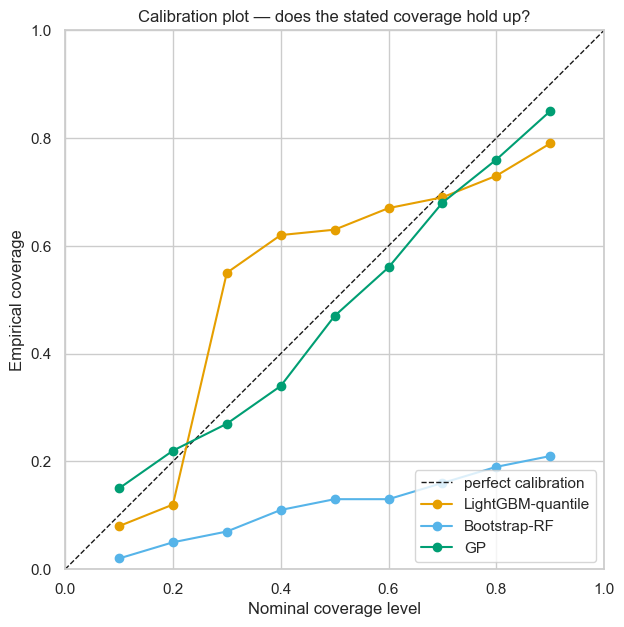

In [57]:
from scipy.stats import norm

nominal = np.arange(0.1, 0.91, 0.1)
lo_qs = np.round((1 - nominal) / 2, 4)
hi_qs = np.round((1 + nominal) / 2, 4)

# 1. Make sure every needed LightGBM quantile is fitted
needed = sorted(set(np.concatenate([lo_qs, hi_qs])))
for q in needed:
    if q not in preds:
        m = lgb.LGBMRegressor(alpha=q, **common_params)
        m.fit(X_train, y_train)
        models[q] = m
        preds[q]  = m.predict(X_test)

# 2. Empirical coverage at each nominal level for each method
cov_curves = {'LightGBM-quantile': [], 'Bootstrap-RF': [], 'GP': []}

for lo_q, hi_q, alpha in zip(lo_qs, hi_qs, nominal):
    lo = np.minimum(preds[lo_q], preds[hi_q])
    hi = np.maximum(preds[lo_q], preds[hi_q])
    cov_curves['LightGBM-quantile'].append(
        np.mean((y_test >= lo) & (y_test <= hi)))

    lo_b = np.percentile(boot_preds, 100 * lo_q, axis=0)
    hi_b = np.percentile(boot_preds, 100 * hi_q, axis=0)
    cov_curves['Bootstrap-RF'].append(
        np.mean((y_test >= lo_b) & (y_test <= hi_b)))

    z = norm.ppf(hi_q)
    cov_curves['GP'].append(
        np.mean(np.abs(y_test - gp_mu) <= z * gp_sigma))

# 3. Plot
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='perfect calibration')
for method, covs in cov_curves.items():
    ax.plot(nominal, covs, 'o-', lw=1.5, label=method)
ax.set_xlabel('Nominal coverage level')
ax.set_ylabel('Empirical coverage')
ax.set_title('Calibration plot — does the stated coverage hold up?')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.legend(loc='lower right')
plt.show()


---

# Week 6 — Fleet-level survival analysis

**Required reading**: lifelines documentation — https://lifelines.readthedocs.io/

Note: you may need to restart the kernel to use updated packages.


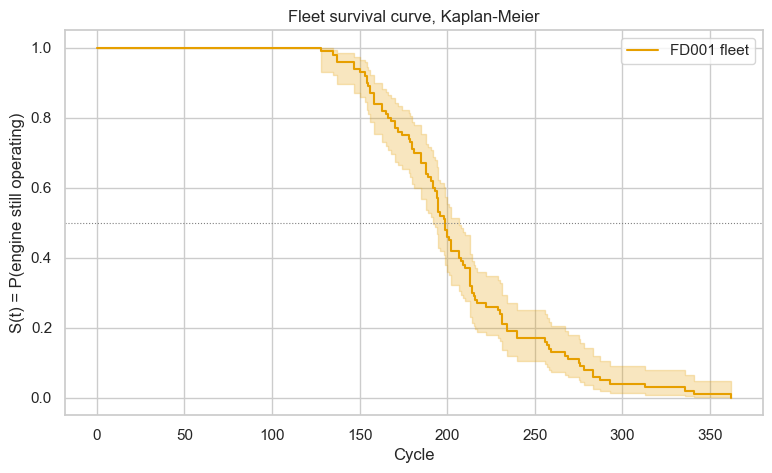

In [60]:
# Cell: Kaplan-Meier estimator for fleet survival
# --------
# For each training engine, you observe failure at its last cycle (uncensored).
# Build a lifelines.KaplanMeierFitter. Plot the survival curve.
# Interpret: at cycle X, what fraction of engines are still operating?

%pip install lifelines
from lifelines import KaplanMeierFitter, WeibullFitter

# YOUR CODE HERE

durations = train.groupby('unit_id')['cycle'].max().values
events = np.ones_like(durations)

kmf = KaplanMeierFitter().fit(durations, events, label = 'FD001 fleet')

fig, ax = plt.subplots(figsize = (9, 5))
kmf.plot_survival_function(ax = ax, ci_show = True)
ax.set_xlabel('Cycle')
ax.set_ylabel('S(t) = P(engine still operating)')
ax.set_title('Fleet survival curve, Kaplan-Meier')
ax.axhline(0.5, color = 'gray', ls = ':', lw = 0.8)
plt.show()

 Shape β = 4.41
 Scale λ = 225.0 cycles
Interpretation:  β = 4.41 -> Wear-out failure (expected for turbofans)


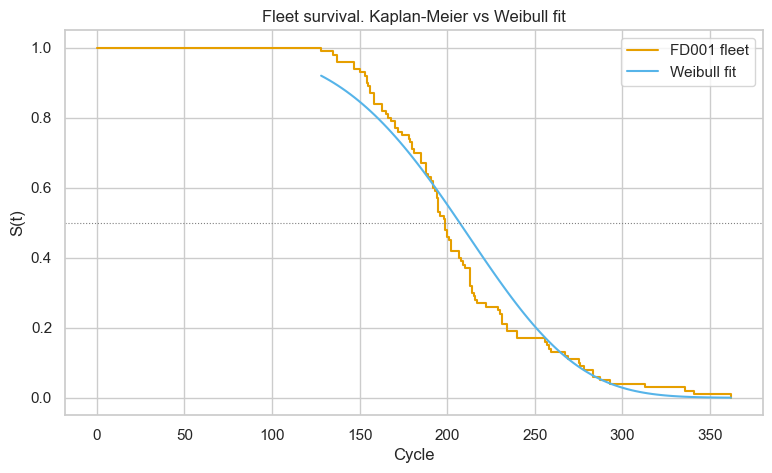

In [62]:
# Cell: Fit a Weibull distribution
# --------
# WeibullFitter gives shape (β) and scale (λ). Interpret β:
#   β < 1: infant mortality (unlikely for turbofans)
#   β ≈ 1: random failures (exponential)
#   β > 1: wear-out failures (expected for turbofans)
#
# Print β and λ. Plot Weibull survival curve on the same axes as KM for comparison.

# YOUR CODE HERE
wf = WeibullFitter().fit(durations, events, label = 'Weibull fit')

beta = wf.rho_
lam = wf.lambda_
print(f' Shape β = {beta:.2f}')
print(f' Scale λ = {lam:.1f} cycles')

if beta > 1:
    interp = 'Wear-out failure (expected for turbofans)'
elif beta < 1:
    interp = 'Infant mortality (Unexpected)'
else:
    inter = 'Random failure'

print(f'Interpretation:  β = {beta:.2f} -> {interp}')

fig, ax = plt.subplots(figsize = (9,5))
kmf.plot_survival_function(ax = ax, ci_show = False)
wf.plot_survival_function(ax = ax, ci_show = False)
ax.set_xlabel('Cycle')
ax.set_ylabel('S(t)')
ax.set_title('Fleet survival. Kaplan-Meier vs Weibull fit')
ax.axhline(0.5, color = 'grey', ls = ':', lw = 0.8)
ax.legend()
plt.show()

In [67]:
# Cell: Cox proportional hazards with sensor covariates
# --------
# Prepare a "long-format" survival DataFrame:
#   - One row per engine
#   - Columns: duration (lifetime), event (always 1 for fully-failed training engines),
#     and sensor-derived covariates (e.g., mean z-score in last 30 cycles, anomaly
#     score at truncation point, etc.)
#
# Fit CoxPHFitter. Print the hazard ratios.
# Engines with high z-scores should have hazard ratio > 1 (higher failure risk).

from lifelines import CoxPHFitter

# YOUR CODE HERE

records = []
for uid, g in train.groupby('unit_id'):
    g = g.sort_values('cycle')
    L = g['cycle'].max()
    if L < WINDOW:
        continue

    last_obs = g.tail(WINDOW)
    last_kf  = kalman_train[uid].tail(WINDOW)
    z_cols   = [f'{s}_z' for s in USEFUL_SENSORS]

    records.append({
        'unit_id':         uid,
        'duration':        L,
        'event':           1,
        'mean_abs_zscore': float(last_obs[z_cols].abs().mean().mean()),
        'mean_anomaly':    float(last_kf['anomaly'].mean()),
        'final_anomaly':   float(last_kf['anomaly'].iloc[-1]),
    })

surv_train = pd.DataFrame(records).set_index('unit_id')
print(surv_train.head())

cph = CoxPHFitter().fit(surv_train, duration_col='duration', event_col='event')
cph.print_summary(decimals=3)

hr = np.exp(cph.params_).sort_values(ascending=False)
print(f'\nConcordance index: {cph.concordance_index_:.3f}')
print('\nHazard ratios (>1 = increased failure risk):')
print(hr.round(2))


         duration  event  mean_abs_zscore  mean_anomaly  final_anomaly
unit_id                                                               
1             192      1         4.263194     13.517094      12.253230
2             287      1         6.455328     15.930803      29.463247
3             179      1         6.431272     33.034004      58.289404
4             189      1         6.709688     42.122901      72.725722
5             269      1         6.776922     16.282213      19.353240


<lifelines.CoxPHFitter: fitted with 100 total observations, 0 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 100
number of events observed = 100
   partial log-likelihood = -344.149
         time fit was run = 2026-05-14 19:48:16 UTC

---
                  coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                               
mean_abs_zscore -0.732      0.481      0.129           -0.986           -0.479                0.373                0.620
mean_anomaly     0.130      1.139      0.025            0.082            0.179                1.085                1.196
final_anomaly   -0.007      0.993      0.002           -0.011           -0.002                0.989                0.998

                  cmp to      z       p   -log2(p)
covariate                                         
mean_abs_zscore    0.000 -5.657 <0.0005     25.950
mean_anomaly       0.000  5.243 <0.0005     22.596
final_anomaly      0.000 -2.778   0.005      7.513
---
Concordance = 0.718
Partial AIC = 694.297
log-likelihood ratio test = 39.182 on 3 df
-log2(p) of ll-ratio test = 25.908


Concordance index: 0.718

Hazard ratios (>1 = increased failure risk):
covariate
mean_anomaly       1.14
final_anomaly      0.99
mean_abs_zscore    0.48
Name: coef, dtype: float64


Top 15 most-urgent engines (Cox-ranked):
         current_age  mean_abs_zscore  mean_anomaly  final_anomaly  P_fail_50  \
unit_id                                                                         
8                166         1.370000     15.439093       7.754516   0.999999   
93               244         1.919329     11.936530       9.056608   0.999995   
89               177         1.082178     12.191793      10.995677   0.999991   
10               192         1.480408     11.710718       8.300778   0.999983   
29               171         1.394484     12.354725       9.508726   0.999912   
13               195         1.467587     10.958274      11.389220   0.999900   
84               172         1.790896     14.097075      14.059248   0.999807   
91               234         2.044710     11.712408      18.628547   0.999758   
12               217         1.577075     12.625027      13.821650   0.999756   
43               172         1.435901     11.272162      12.380954  

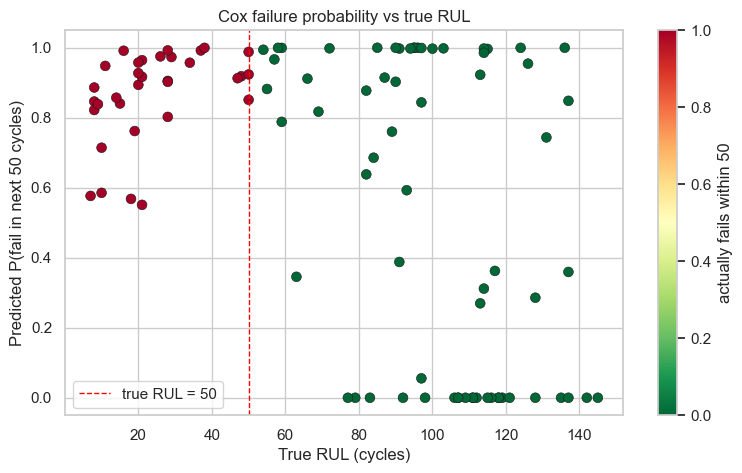

In [68]:
# Cell: Probability of failure in next N cycles
# --------
# For each test engine, given its current sensor state, use the Cox model to compute:
#   P(fails within next 50 cycles | current state)
# This is one of the most actionable outputs for a maintenance planner.

# YOUR CODE HERE

N_AHEAD = 50
WINDOW  = 30   # must match the Cox training cell

# Ensure Kalman + anomaly results exist for test engines
if 'kalman_test' not in globals():
    kalman_test = {}
    for uid, g in test.groupby('unit_id'):
        df = kalman_filter_engine(g, USEFUL_SENSORS)
        df['anomaly'] = anomaly_score(df, USEFUL_SENSORS)
        kalman_test[uid] = df

# Build covariates at each test engine's truncation point
records = []
for uid, g in test.groupby('unit_id'):
    g = g.sort_values('cycle')
    T = g['cycle'].max()
    if T < WINDOW:
        continue
    last_obs = g.tail(WINDOW)
    last_kf  = kalman_test[uid].tail(WINDOW)
    z_cols   = [f'{s}_z' for s in USEFUL_SENSORS]
    records.append({
        'unit_id':         uid,
        'current_age':     T,
        'mean_abs_zscore': float(last_obs[z_cols].abs().mean().mean()),
        'mean_anomaly':    float(last_kf['anomaly'].mean()),
        'final_anomaly':   float(last_kf['anomaly'].iloc[-1]),
    })

test_state = pd.DataFrame(records).set_index('unit_id')
covar_cols = ['mean_abs_zscore', 'mean_anomaly', 'final_anomaly']

# Survival probabilities at each engine's "now" and "now + N_AHEAD"
T_now = test_state['current_age'].values
T_fut = T_now + N_AHEAD
all_times = sorted(set(np.concatenate([T_now, T_fut])))
surv_df = cph.predict_survival_function(test_state[covar_cols], times=all_times)

p_fail = []
for i in range(len(test_state)):
    s_now = surv_df.iloc[:, i].loc[T_now[i]]
    s_fut = surv_df.iloc[:, i].loc[T_fut[i]]
    p = 1.0 - (s_fut / s_now) if s_now > 0 else 1.0
    p_fail.append(float(p))

test_state['P_fail_50'] = p_fail
test_state['true_RUL']  = rul.loc[test_state.index, 'RUL'].values
test_state['actually_fails_in_50'] = (test_state['true_RUL'] <= N_AHEAD).astype(int)

print('Top 15 most-urgent engines (Cox-ranked):')
print(test_state.sort_values('P_fail_50', ascending=False).head(15))

# Visual sanity check
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(test_state['true_RUL'], test_state['P_fail_50'],
                c=test_state['actually_fails_in_50'], cmap='RdYlGn_r',
                s=50, edgecolor='k', linewidth=0.4)
ax.axvline(N_AHEAD, color='red', ls='--', lw=1,
           label=f'true RUL = {N_AHEAD}')
ax.set_xlabel('True RUL (cycles)')
ax.set_ylabel(f'Predicted P(fail in next {N_AHEAD} cycles)')
ax.set_title('Cox failure probability vs true RUL')
ax.legend()
fig.colorbar(sc, label='actually fails within 50')
plt.show()


---

# Week 7 — Dashboard and report

Build a Streamlit app with the following views. Save as `app.py` and run with `streamlit run app.py`.

In [77]:
import plotly.graph_objects as go

uids = sorted(lgb_per_engine)
p10  = np.array([lgb_per_engine[u]['p10'] for u in uids])
p50  = np.array([lgb_per_engine[u]['p50'] for u in uids])
p90  = np.array([lgb_per_engine[u]['p90'] for u in uids])

# 1. Fleet histogram
fig_hist = go.Figure(go.Histogram(x=p50, nbinsx=20))
fig_hist.update_layout(title='Fleet-wide predicted RUL distribution',
                       xaxis_title='Predicted RUL median (cycles)',
                       yaxis_title='Engines')

# 2. Per-engine prediction intervals (sorted)
order = np.argsort(p50)
xs = list(range(len(uids)))
fig_int = go.Figure()
fig_int.add_trace(go.Scatter(x=xs, y=p90[order], mode='lines',
                             line=dict(width=0), showlegend=False))
fig_int.add_trace(go.Scatter(x=xs, y=p10[order], mode='lines',
                             line=dict(width=0), fill='tonexty',
                             fillcolor='rgba(0,100,200,0.3)', name='80% interval'))
fig_int.add_trace(go.Scatter(x=xs, y=p50[order], mode='lines', name='median'))
fig_int.update_layout(title='Per-engine 80% prediction intervals',
                      xaxis_title='Test engine (sorted by predicted RUL)',
                      yaxis_title='RUL (cycles)')

# 3. Maintenance priority table
rows = []
for u in uids:
    p10v, p50v = lgb_per_engine[u]['p10'], lgb_per_engine[u]['p50']
    pf = float(test_state.loc[u, 'P_fail_50']) if u in test_state.index else np.nan
    if (not np.isnan(pf) and pf >= 0.7) or p10v < 20:
        action = 'GROUND'
    elif (not np.isnan(pf) and pf >= 0.3) or p10v < 50:
        action = 'INSPECT'
    else:
        action = 'continue'
    rows.append({'unit_id': u, 'RUL_median': round(p50v, 1),
                 'RUL_p10': round(p10v, 1),
                 'P_fail_50': round(pf, 2) if not np.isnan(pf) else None,
                 'action': action})

priority = {'GROUND': 0, 'INSPECT': 1, 'continue': 2}
df_action = (pd.DataFrame(rows)
             .assign(_pri=lambda d: d['action'].map(priority))
             .sort_values(['_pri', 'P_fail_50'], ascending=[True, False])
             .drop(columns='_pri'))

def table_html(df):
    color = {'GROUND': '#ff7777', 'INSPECT': '#ffcc77', 'continue': 'white'}
    body = ''.join(
        f'<tr style="background:{color[r.action]}">'
        f'<td>{r.unit_id}</td><td>{r.RUL_median}</td><td>{r.RUL_p10}</td>'
        f'<td>{r.P_fail_50}</td><td><b>{r.action}</b></td></tr>'
        for r in df.itertuples()
    )
    return ('<table border=1 cellpadding=6 style="border-collapse:collapse">'
            '<tr><th>Unit</th><th>RUL median</th><th>RUL 10%</th>'
            '<th>P(fail in 50)</th><th>Action</th></tr>'
            f'{body}</table>')

# Stitch into one HTML file
with open('fleet_report.html', 'w') as f:
    f.write('<html><head><title>Turbofan Fleet Monitor</title></head>')
    f.write('<body style="font-family:sans-serif;max-width:1100px;margin:auto">')
    f.write('<h1>Turbofan Fleet Health Monitor</h1>')
    f.write('<h2>Fleet RUL distribution</h2>')
    f.write(fig_hist.to_html(full_html=False, include_plotlyjs='cdn'))
    f.write('<h2>Per-engine prediction intervals</h2>')
    f.write(fig_int.to_html(full_html=False, include_plotlyjs=False))
    f.write('<h2>Maintenance plan</h2>')
    f.write(table_html(df_action))
    f.write('</body></html>')

print('Wrote fleet_report.html — double-click to open in your browser.')


Wrote fleet_report.html — double-click to open in your browser.


In [ ]:
# Cell: Write-up structure
# --------
# Convert this notebook (or a clean copy of it) into a report with these sections:
#   1. Introduction (what's the problem, why does it matter)
#   2. Data (CMAPSS description + your EDA findings)
#   3. Methods (Kalman filtering, regression, UQ, survival — one paragraph each)
#   4. Results (benchmark table, calibration plot, scenario analyses)
#   5. Discussion (limitations, what you'd do with more time)
#   6. References (Saxena et al. 2008, Heimes 2008, etc.)
#
# Export to HTML via File → Export Notebook as → HTML.
# Target length: 10-15 pages. This is portfolio-grade material.

print('No code this cell — write your report.')


---

# Week 8 — Extension (pick one)

## Option 1: Hybrid physics + data-driven prognostics

Read **Liao and Köttig 2014, "Review of hybrid prognostics approaches"** (IEEE Transactions on Reliability). Implement a simple hybrid: fit a physics-inspired exponential degradation model `y = a·exp(b·t) + ε` to each engine's anomaly score, then use the fitted parameters as additional features in your regression model.

## Option 2: Extend to FD002 (multiple operating conditions)

FD002 has 6 operating condition regimes. Engines transition between them during flight. This requires **regime-based normalization**: compute baselines per (engine, regime) instead of per engine only. Cluster operating conditions first (`sklearn.cluster.KMeans` on op1, op2, op3), then apply your pipeline within each regime.

## Option 3: Deploy to Streamlit Community Cloud

Push to GitHub. Sign up at https://streamlit.io/cloud (free). Connect repo. Your app is live at a URL you can share. This teaches the deployment side most students skip.

In [85]:
# Option 1  - Hybrid physics + data driven prognostics

from scipy.optimize import curve_fit

def exp_model(t, a, b):
    return a * np.exp(b * t)

def fit_exp_per_engine(kalman_dict):
    rows = []
    for uid, df in kalman_dict.items():
        cycles = df['cycle'].values
        scores = df['anomaly'].values
        mid = len(cycles) // 2
        t = cycles[mid:]
        y = scores[mid:]
        try:
            (a, b), _ = curve_fit(exp_model, t - t[0], y, p0 = [max(y[0], 1.0), 0.01], bounds = ([1e-3, 0], [1e6, 1.0]), maxfev = 2000)
        except Exception:
            a, b = np.nan, np.nan
        rows.append({'unit_id': uid, 'phys_a': a, 'phys_b': b})
    
    return pd.DataFrame(rows).set_index('unit_id')

phys_train = fit_exp_per_engine(kalman_train)
phys_test = fit_exp_per_engine(kalman_test)

for col in ['phys_a', 'phys_b']:
    med = phys_train[col].median()
    phys_train[col] = phys_train[col].fillna(med)
    phys_test[col] = phys_test[col].fillna(med)

train_phys = train_sorted['unit_id'].map(phys_train['phys_a']).rename('phys_a').to_frame()
train_phys['phys_b'] = train_sorted['unit_id'].map(phys_train['phys_b']).values

test_phys_last = phys_test.loc[rul.index]
X_train_h = np.column_stack([X_train, train_phys.values])
X_test_h = np.column_stack([X_test, test_phys_last.values])

lgb_h = lgb.LGBMRegressor(alpha = 0.5, **common_params)
lgb_h.fit(X_train_h, y_train)
pred_h = lgb_h.predict(X_test_h)

rmse_h = float(np.sqrt(np.mean((pred_h - y_test) ** 2)))
score_h = cmapss_score(pred_h, y_test)
print(f'Hybrid (LightGBM + physics features)')
print(f'RMSE: {rmse_h:.2f}')
print(f'CMAPSS: {score_h:.1f}')
print(f' vs LightGBM-median baseline: RMSE = {rmse_h - rmse_lgb:+.2f}')

Hybrid (LightGBM + physics features)
RMSE: 16.11
CMAPSS: 467.6
 vs LightGBM-median baseline: RMSE = -0.86


/Users/mikkelpeluffojohansen/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [99]:
# Option 2 - Multiple operating conditions - FD002

from sklearn.cluster import KMeans

train2 = pd.read_csv(DATA_DIR / 'train_FD002.txt', sep=r'\s+', header=None, names=col_names)
test2  = pd.read_csv(DATA_DIR / 'test_FD002.txt',  sep=r'\s+', header=None, names=col_names)
rul2   = pd.read_csv(DATA_DIR / 'RUL_FD002.txt',   sep=r'\s+', header=None, names=['RUL'])
rul2.index = np.arange(1, len(rul2) + 1)
rul2.index.name = 'unit_id'

print(f'FD002 train: {train2.shape}, {train2["unit_id"].nunique()} engines')
print(f'FD002 test: {test2.shape}, {test2["unit_id"].nunique()} engines')

ops_train = train2[['op1', 'op2', 'op3']].values
km = KMeans(n_clusters = 6, random_state = 42, n_init = 10).fit(ops_train)
train2['regime'] = km.predict(ops_train)
test2['regime'] = km.predict(test2[['op1', 'op2', 'op3']].values)

print('Regime distribution (train):')
print(train2['regime'].value_counts().sort_index())

def zscore_by_regime(df, sensors):
    df = df.copy()
    means = df.groupby(['unit_id', 'regime'])[sensors].transform('mean')
    stds = df.groupby(['unit_id', 'regime'])[sensors].transform('std').replace(0, 1)
    
    for s in sensors:
        df[f'{s}_z'] = ((df[s] - means[s]) / stds[s])
    return df

sensors_all = [f's{i}' for i in range(1, 22)]
sensor_var = train2.groupby('regime')[sensors_all].var().mean()
USEFUL_SENSORS_OO2 = sensor_var[sensor_var > 1e-6].index.tolist()
print(f'FD002 useful sensors after regime-aware variance filter: {USEFUL_SENSORS_OO2}')

train2 = zscore_by_regime(train2, USEFUL_SENSORS_OO2)
test2 = zscore_by_regime(test2, USEFUL_SENSORS_OO2)

train2['RUL'] = (train2.groupby('unit_id')['cycle'].transform('max') - train2['cycle']).clip(upper = RUL_CLIP)

z_cols2 = [f'{s}_z' for s in USEFUL_SENSORS_OO2]
def build_features2(df):
    df = df.sort_values(['unit_id', 'cycle'])
    g = df.groupby('unit_id')[z_cols2].rolling(window = 10, min_periods = 1)
    cur = df[z_cols2]
    means = g.mean().reset_index(level = 0, drop = True).add_suffix('_mean')
    stds = g.std().reset_index(level = 0, drop = True).add_suffix('_std').fillna(0)
    mins = g.min().reset_index(level = 0, drop = True).add_suffix('_min')
    maxs = g.max().reset_index(level = 0, drop = True).add_suffix('_max')

    return pd.concat([cur, means, stds, mins, maxs], axis = 1).loc[df.index]

X_train2_df = build_features2(train2_sorted)
feature_cols = X_train2_df.columns
X_train2 = X_train2_df.values
y_train2 = train2_sorted['RUL'].values

last_idx2 = test2_sorted.groupby('unit_id')['cycle'].idxmax()
X_test2_df = build_features2(test2_sorted)
X_test2 = X_test2_df.reindex(columns=feature_cols, fill_value=0).loc[last_idx2].values
y_test2 = np.minimum(rul2['RUL'].values, RUL_CLIP)

lgb2 = lgb.LGBMRegressor(alpha=0.5, **common_params)
lgb2.fit(X_train2, y_train2)
pred2 = lgb2.predict(X_test2)

rmse2  = float(np.sqrt(np.mean((pred2 - y_test2) ** 2)))
score2 = cmapss_score(pred2, y_test2)
print(f'FD002 LightGBM-median')
print(f'  RMSE:   {rmse2:.2f}')
print(f'  CMAPSS: {score2:.1f}')


FD002 train: (53759, 26), 260 engines
FD002 test: (33991, 26), 259 engines
Regime distribution (train):
regime
0    13458
1     8122
2     8002
3     8044
4     8096
5     8037
Name: count, dtype: int64
FD002 useful sensors after regime-aware variance filter: ['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's20', 's21']
FD002 LightGBM-median
  RMSE:   47.65
  CMAPSS: 24316.6


/Users/mikkelpeluffojohansen/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [105]:
%%bash
cd "/Users/mikkelpeluffojohansen/Desktop/Notebooks/Projects/Project A"

cat > requirements.txt << 'EOF'
streamlit
numpy
pandas
matplotlib
scikit-learn
lightgbm
filterpy
lifelines
properscoring
plotly
EOF

cat > .gitignore << 'EOF'
*.txt
__pycache__/
.ipynb_checkpoints/
EOF

git config --global user.name  "Mikkel Peluffo Johansen"
git config --global user.email "mikkelguidopeluffo@gmail.com"

git init
git add app.py requirements.txt .gitignore
git commit -m "Initial Streamlit app for turbofan fleet monitor"

gh repo create turbofan-fleet-monitor --public --source=. --remote=origin --push


Reinitialized existing Git repository in /Users/mikkelpeluffojohansen/Desktop/Notebooks/Projects/Project A/.git/


fatal: pathspec 'app.py' did not match any files


On branch main

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.DS_Store
	.gitignore
	Program A; Engine_Performance.ipynb
	REPORT.md
	fleet_report.html

nothing added to commit but untracked files present (use "git add" to track)


`--push` enabled but no commits found in /Users/mikkelpeluffojohansen/Desktop/Notebooks/Projects/Project A


CalledProcessError: Command 'b'cd "/Users/mikkelpeluffojohansen/Desktop/Notebooks/Projects/Project A"\n\ncat > requirements.txt << \'EOF\'\nstreamlit\nnumpy\npandas\nmatplotlib\nscikit-learn\nlightgbm\nfilterpy\nlifelines\nproperscoring\nplotly\nEOF\n\ncat > .gitignore << \'EOF\'\n*.txt\n__pycache__/\n.ipynb_checkpoints/\nEOF\n\ngit config --global user.name  "Mikkel Peluffo Johansen"\ngit config --global user.email "mikkelguidopeluffo@gmail.com"\n\ngit init\ngit add app.py requirements.txt .gitignore\ngit commit -m "Initial Streamlit app for turbofan fleet monitor"\n\ngh repo create turbofan-fleet-monitor --public --source=. --remote=origin --push\n'' returned non-zero exit status 1.

---

## Core references for Program A

- **NASA PCoE Data Repository** — https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/
- **Roger Labbe, "Kalman and Bayesian Filters in Python"** — https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python
- **James et al., "An Introduction to Statistical Learning"** — https://www.statlearning.com/
- **Rasmussen & Williams, "Gaussian Processes for Machine Learning"** — http://www.gaussianprocess.org/gpml/
- **Saxena et al. 2008**, damage propagation modeling (NASA NTRS)
- **Heimes 2008**, recurrent neural nets for RUL estimation
- **Kim, An, Choi 2017**, "Prognostics and Health Management of Engineering Systems" (Springer)
- **lifelines** — https://lifelines.readthedocs.io/
- **filterpy** — https://filterpy.readthedocs.io/

Ping me when you hit the first wall — good luck.